In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score
from sklearn.ensemble import RandomForestClassifier ,GradientBoostingClassifier
from sklearn.metrics import classification_report , roc_auc_score , confusion_matrix ,roc_curve, auc

In [10]:
df = pd.read_csv(r"C:\Users\kmahe\Downloads\HR_Attrition.csv")
print(df.head(10))
print(df.columns)
print("No. of Rows and Column",df.shape)
target = "Attrition"
print("target column" , target)
print(df['Attrition'].unique())

total_employees =  len(df)
attrition_counts = df["Attrition"].value_counts()
print(attrition_counts)
employees_left = (df["Attrition"]=="Yes").sum()
employees_stayed = (df["Attrition"]=='No').sum()
attrition_rate = (employees_left/total_employees)*100
print(f"Attrition Rate:{attrition_rate:.2f}%")

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   
5   32        No  Travel_Frequently       1005  Research & Development   
6   59        No      Travel_Rarely       1324  Research & Development   
7   30        No      Travel_Rarely       1358  Research & Development   
8   38        No  Travel_Frequently        216  Research & Development   
9   36        No      Travel_Rarely       1299  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8      

In [3]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(exclude=['number']).columns.tolist()

print(f"Total Numeric Columns: {len(numeric_cols)}")
print(f"Total Categorical Columns: {len(categorical_cols)}")

print("Employees Left", employees_left)
print("Employees Stayed", employees_stayed)

Total Numeric Columns: 26
Total Categorical Columns: 9
Employees Left 237
Employees Stayed 1233


According to my opinion , the attrition rate of the company is 16.12% which is slightly more than the average attrition rate which is 10-15% normally . So , In my opinion , The Attrition rate is imbalanced .

In [4]:
df.isnull().sum()

columns_to_drop=[
    'EmployeeNumber',
    'Over18',
    'StandardHours'
]
exist_col = [col for col in columns_to_drop
             if col in df.columns]

df.drop(columns=exist_col , inplace=True)
print("Columns Dropped Successfully")

Columns Dropped Successfully


In [5]:
df['Attrition'] = df['Attrition'].map({
    'Yes':1,
    'No':0
})
df["Attrition"].unique()

categorical_cols = df.select_dtypes(
    include=['object','string']
).columns
df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first = True
)
df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,1,2,94,3,2,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,1,3,61,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,1,4,92,2,1,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,1,4,56,3,1,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,1,40,3,1,...,True,False,False,False,False,False,False,True,False,False


In [6]:
X = df.drop('Attrition',axis=1)
y = df['Attrition']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X = pd.DataFrame(
    X_scaled,
    columns = X.columns
)
X.head()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.446350,0.742527,-1.010909,-0.891688,0.0,-0.660531,1.383138,0.379672,-0.057788,1.153254,...,-0.462464,-0.273059,-0.330808,-0.239904,-0.497873,1.873287,-0.244625,-0.918921,1.458650,1.591746
1,1.322365,-1.297775,-0.147150,-1.868426,0.0,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,...,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,-0.628241
2,0.008343,1.414363,-0.887515,-0.891688,0.0,1.169781,1.284725,-1.026167,-0.961486,0.246200,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.918921,1.458650,1.591746
3,-0.429664,1.461466,-0.764121,1.061787,0.0,1.169781,-0.486709,0.379672,-0.961486,0.246200,...,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,1.591746
4,-1.086676,-0.524295,-0.887515,-1.868426,0.0,-1.575686,-1.274014,0.379672,-0.961486,-0.660853,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,1.088232,-0.685565,-0.628241


In [7]:
print('feature Shape' , X.shape)
print('Target shape' , y.shape)

feature Shape (1470, 45)
Target shape (1470,)


So in this , It first check for the missing values and then handle them .
after that , it can drop the columns which are not require in next . So , we can drop them .
It then convert the Attrition from 'Yes/no' to '1/0' . and then encoded all the remaining columns after the drop .
In the last , There is measure of te numeric feature on the basis of the standard scaler .

Attrition                      No        Yes
Department                                  
Human Resources         80.952381  19.047619
Research & Development  86.160250  13.839750
Sales                   79.372197  20.627803


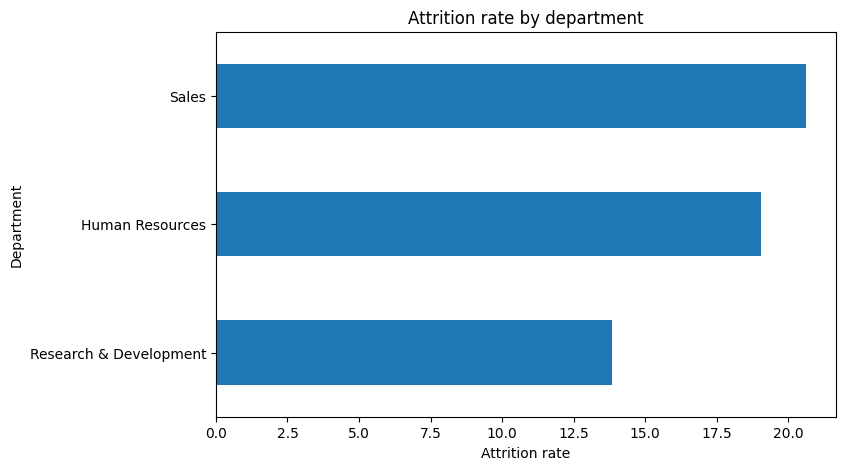

In [64]:
dept_attrition = pd.crosstab(
    df['Department'],
    df['Attrition'],
    normalize = 'index'
)*100

print(dept_attrition)

dept_attrition['Yes'].sort_values().plot(
    kind='barh',
    figsize=(8,5)
)
plt.title('Attrition rate by department')
plt.xlabel('Attrition rate')
plt.show()

As it is Exploitary data Analysis . So , it require visual representation .
  So , firstly in this , there is data thats shows the department-wise Attrition in the company . As the sales Department loses employee most in the company .

Attrition                         No        Yes
JobRole                                        
Healthcare Representative  93.129771   6.870229
Human Resources            76.923077  23.076923
Laboratory Technician      76.061776  23.938224
Manager                    95.098039   4.901961
Manufacturing Director     93.103448   6.896552
Research Director          97.500000   2.500000
Research Scientist         83.904110  16.095890
Sales Executive            82.515337  17.484663
Sales Representative       60.240964  39.759036


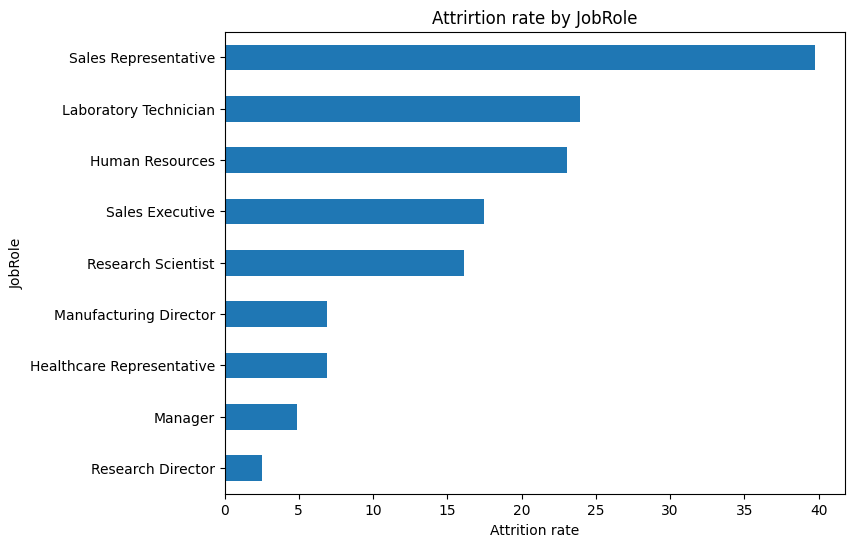

In [12]:
jr_attrition = pd.crosstab(
    df['JobRole'],
    df['Attrition'],
    normalize='index'
)*100

print(jr_attrition)

jr_attrition['Yes'].sort_values().plot(
    kind='barh',
    figsize=(8,6)
)
plt.title('Attrirtion rate by JobRole')
plt.xlabel('Attrition rate')
plt.show()

This Graph shows the JobRole wise Attrition rate in the company . we clearly see that Sales Representative have th highest exit rate in the Sales Department .

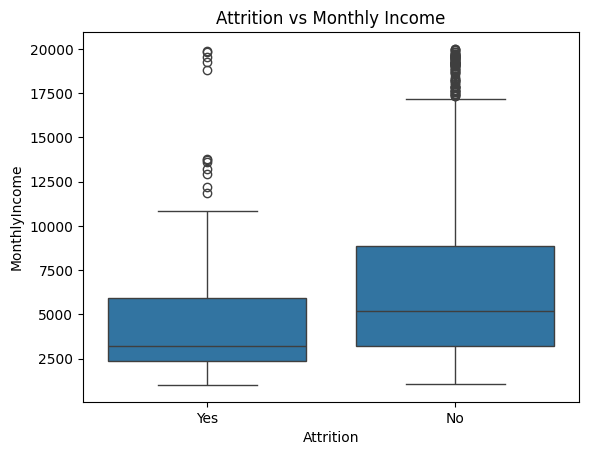

In [58]:
sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df
)
plt.title('Attrition vs Monthly Income')
plt.show()

Attrition              No       Yes
WorkLifeBalance                    
1                0.687500  0.312500
2                0.831395  0.168605
3                0.857783  0.142217
4                0.823529  0.176471


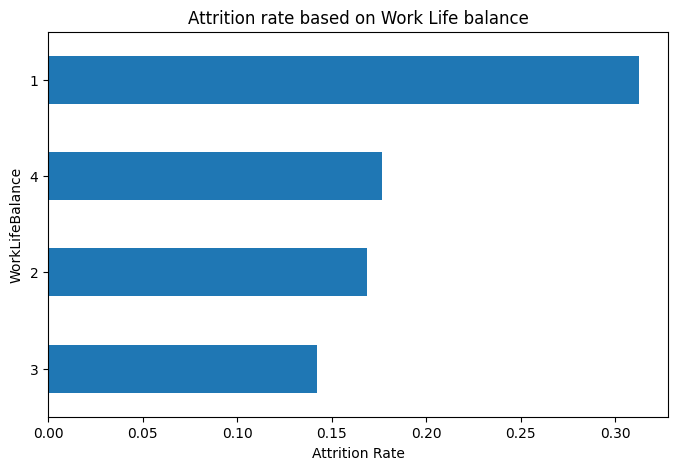

In [14]:
wlb_attrition = pd.crosstab(
    df['WorkLifeBalance'],
    df['Attrition'],
    normalize='index'
)
print(wlb_attrition)

wlb_attrition['Yes'].sort_values().plot(
    kind='barh',
    figsize=(8,5)
)
plt.title('Attrition rate based on Work Life balance')
plt.xlabel("Attrition Rate")
plt.show()

In this , The graph shows the Work-life balance rating in the company  . there is visible pattern that empoyee having '1' as rating to the work-life balance have higher attrition rate as compared to the '4' rating employees . But '4' rating employee left mre than '2' or '3' ratinng employee .
So , there is mixed pattern for the attrition rate on the basis of the Work-life balance .

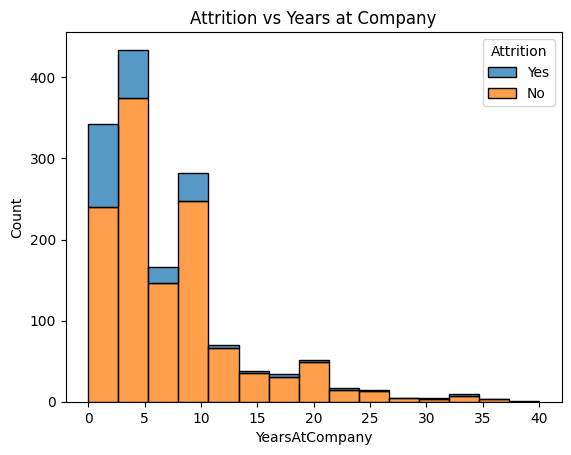

In [15]:
sns.histplot(
    data=df,
    x='YearsAtCompany',
    hue='Attrition',
    multiple='stack',
    bins = 15
)
plt.title('Attrition vs Years at Company')
plt.show()

This Graph shows the Attrition Rate on the basis of the stay in the company . This graph clearly show that employee in phase of 2.5 - 5 years left more i.e. In that phase ,The attrition rate is very high .

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print(X_train.shape)
print(X_test.shape)

(1176, 45)
(294, 45)


In [65]:
lr = LogisticRegression(
    class_weight = 'balanced',
    max_iter = 1000,
    random_state = 42
)

lr.fit(X_train , y_train )

y_pred_lr = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test , y_pred_lr)
lr_precision = precision_score(y_test , y_pred_lr)
lr_recall =  recall_score(y_test , y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print('Logistic Regression Accuracy',lr_accuracy)
                             

Logistic Regression Accuracy 0.7482993197278912


In [28]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8129251700680272


In [30]:
gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

gb_accuracy = accuracy_score(y_test, y_pred_gb)
gb_precision = precision_score(y_test, y_pred_gb)
gb_recall = recall_score(y_test, y_pred_gb)
gb_f1 = f1_score(y_test, y_pred_gb)

print("Gradient Boosting Accuracy:", gb_accuracy)

Gradient Boosting Accuracy: 0.8503401360544217


In [31]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Accuracy': [
        lr_accuracy,
        rf_accuracy,
        gb_accuracy
    ],
    'Precision': [
        lr_precision,
        rf_precision,
        gb_precision
    ],
    'Recall': [
        lr_recall,
        rf_recall,
        gb_recall
    ],
    'F1 Score': [
        lr_f1,
        rf_f1,
        gb_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.748299,0.341176,0.617021,0.439394
1,Random Forest,0.812925,0.366667,0.234043,0.285714
2,Gradient Boosting,0.850340,0.588235,0.212766,0.312500


In this task , it first split data for training and testing .
After that , It handles the imbalance using the class_weight as parameter to train the models on the basis of the Logistic regression , Random Forest and the Gradient boosting by finding thee accuracy , precision , recall-value , f1 score.
After that , there is a comaprison table for all three on the basis of the precision , accuracy , Recall values anf the f1 score .

In [37]:
print('Logistic Regression :\n', classification_report(y_test , y_pred_lr))

print('Random forest :\n' , classification_report(y_test ,y_pred_rf))

print('Gradient Boosting :\n' , classification_report(y_test , y_pred_gb))

Logistic Regression :
               precision    recall  f1-score   support

           0       0.91      0.77      0.84       247
           1       0.34      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.77       294

Random forest :
               precision    recall  f1-score   support

           0       0.86      0.92      0.89       247
           1       0.37      0.23      0.29        47

    accuracy                           0.81       294
   macro avg       0.62      0.58      0.59       294
weighted avg       0.78      0.81      0.80       294

Gradient Boosting :
               precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg 

In this task , All the three model were evaluated on thr basis of the precision , recall and f1_score .

In [39]:
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test)[:,1])

rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

gb_auc = roc_auc_score(y_test, gb.predict_proba(X_test)[:,1])

print("Logistic Regression AUC:", lr_auc)
print("Random Forest AUC:", rf_auc)
print("Gradient Boosting AUC:", gb_auc)

Logistic Regression AUC: 0.798604530967353
Random Forest AUC: 0.7776294254457748
Gradient Boosting AUC: 0.7934361271427341


In this , All three model were evaluated on the basis of the AUC score .

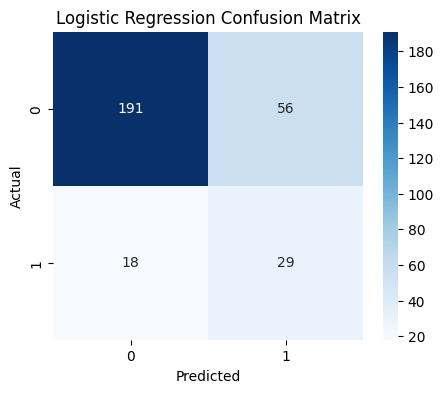

In [43]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm_lr,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

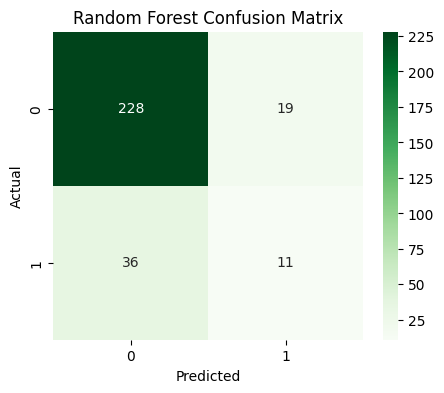

In [44]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf,
            annot=True,
            fmt='d',
            cmap='Greens')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

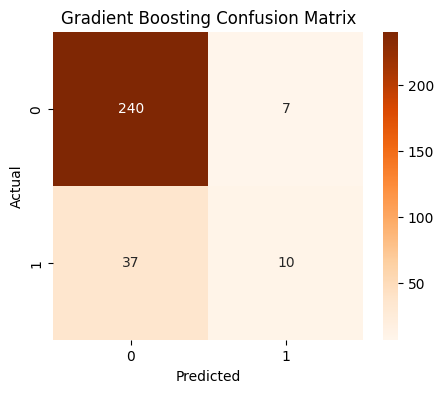

In [45]:
cm_gb = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(5,4))
sns.heatmap(cm_gb,
            annot=True,
            fmt='d',
            cmap='Oranges')

plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In this , All 3 model were evaluate on the basis of the Confusion matrix.

In [50]:
comparison = comparison.copy()

comparison["ROC_AUC"] = [
    lr_auc,
    rf_auc,
    gb_auc
]

comparison.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC_AUC
0,Logistic Regression,0.748299,0.341176,0.617021,0.439394,0.798605
2,Gradient Boosting,0.850340,0.588235,0.212766,0.312500,0.793436
1,Random Forest,0.812925,0.366667,0.234043,0.285714,0.777629


On the basis of all the evaluation , It clearly visible that Random Forest model is very best suited because it's accuracy is way better , precision is also good as comapred  to the Logisticregression whose accuracy is comapratively is low and Gradient bossting whose precision is very high .

In [51]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
10,MonthlyIncome,0.068514
0,Age,0.066324
1,DailyRate,0.052767
17,TotalWorkingYears,0.052428
20,YearsAtCompany,0.045107
23,YearsWithCurrManager,0.045078
44,OverTime_Yes,0.044275
11,MonthlyRate,0.043363
6,HourlyRate,0.042758
2,DistanceFromHome,0.042302


For the best model , Monthlyincome matters te most in predicting the attrition .

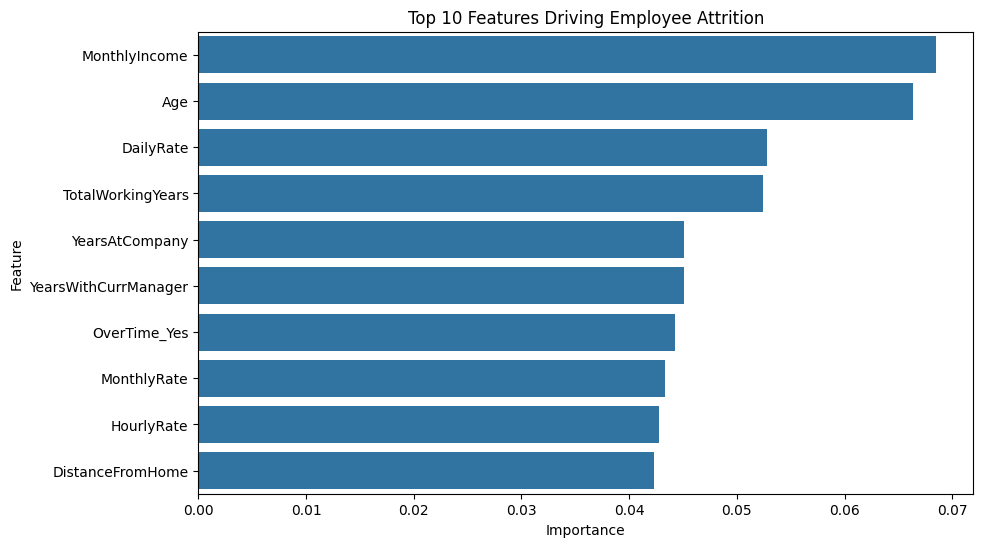

In [53]:
top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Features Driving Employee Attrition")
plt.show()

Here is the top 10 most important feature driving employee exit .

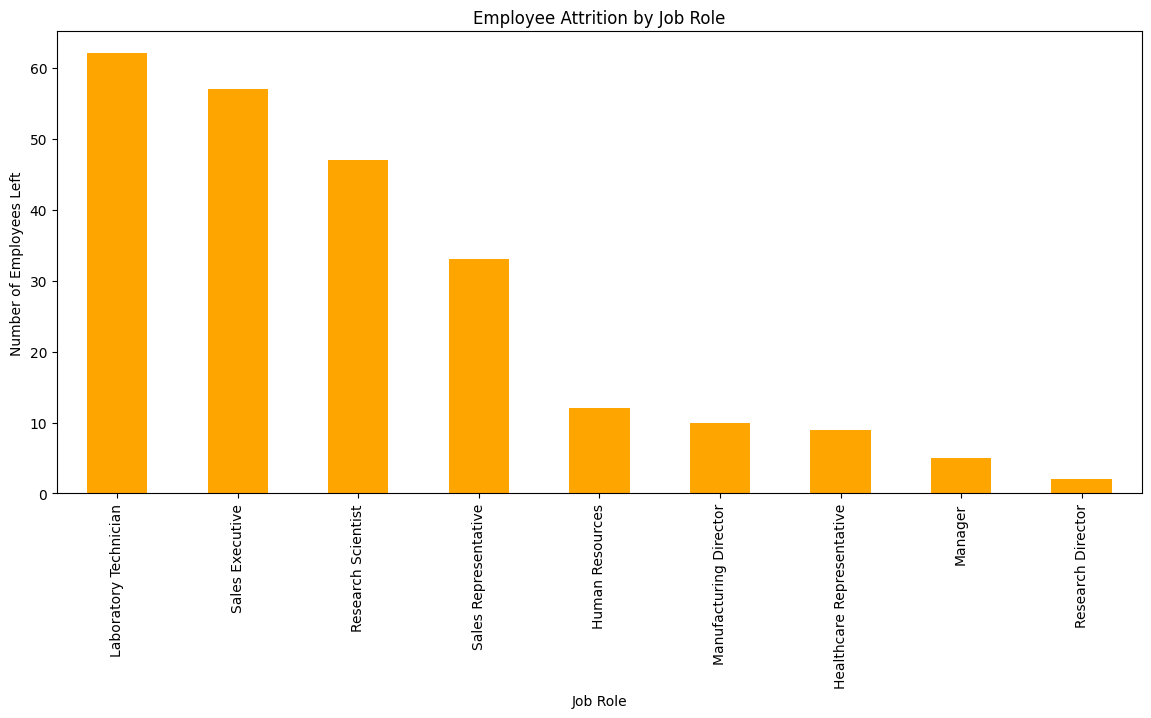

In [56]:
plt.figure(figsize=(14,6))

attrition_dept_role = pd.crosstab(
    df['JobRole'],
    df['Attrition']
)

attrition_dept_role['Yes'].sort_values(ascending=False).plot(
    kind='bar',
    color='orange'
)

plt.title("Employee Attrition by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Number of Employees Left")
plt.show()

This is the bar chart showing attrition rate by Department and Job role in the company .

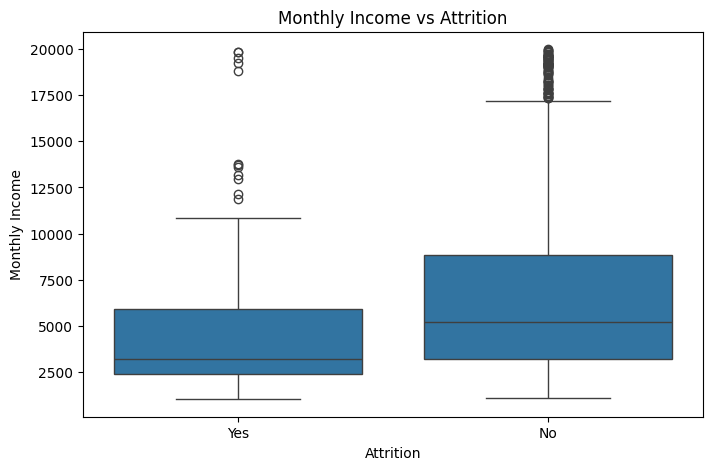

In [57]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df
)

plt.title("Monthly Income vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()

This is the boxpot chart comparing the Monthly income of employees who left vs stayed .

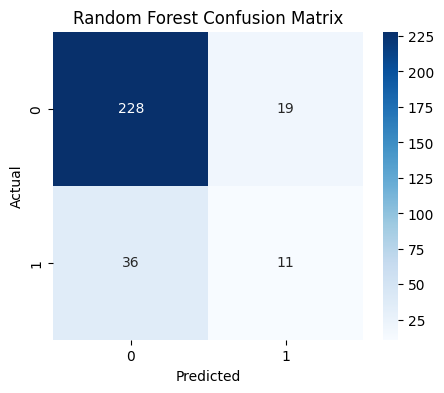

In [59]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

This is confusion matrix heatmap for the random forest model which is the best suit for such scenario .

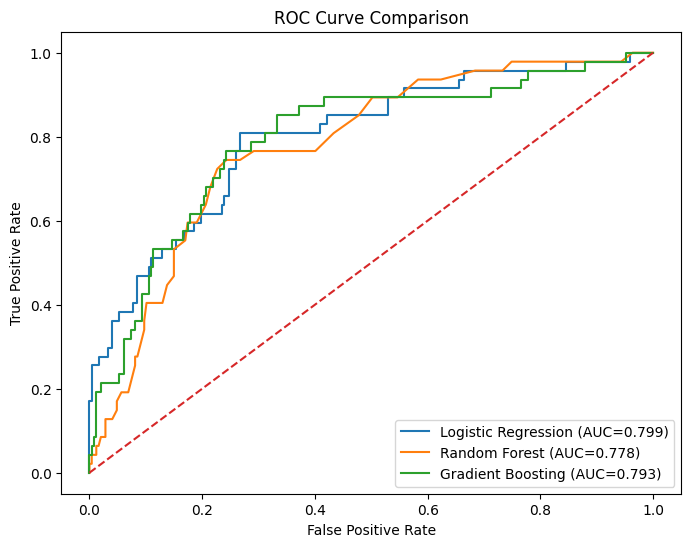

In [63]:
lr_probs = lr.predict_proba(X_test)[:,1]
rf_probs = rf.predict_proba(X_test)[:,1]
gb_probs = gb.predict_proba(X_test)[:,1]

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_probs)

plt.figure(figsize=(8,6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f'Logistic Regression (AUC={auc(lr_fpr, lr_tpr):.3f})'
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f'Random Forest (AUC={auc(rf_fpr, rf_tpr):.3f})'
)

plt.plot(
    gb_fpr,
    gb_tpr,
    label=f'Gradient Boosting (AUC={auc(gb_fpr, gb_tpr):.3f})'
)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

This is the ROC curve that comparing all three models on one graph.

On the basis of that analysis , employee attrition werw MonthlyIncome , Jobsatisfaction and the Overtimerate for the employee.
SalesDepartment and salesRepresentative department shows the most Attrition rate . So , HR require to prioritize them for retention efforts .
No , salary alone doesn't explain attrition . There are more factors that are require like career growth , job satisfaction and worklife balance etc .
HR should discuss with the employee which are not much satisfy with them to find out the problem . It also conduct the develpoment programs for betterment of the employee.
The limitation of the data is that it relies on the historical data of the employee . 